In [1]:
import warnings

warnings.filterwarnings("ignore")

from dotenv import load_dotenv
import os
import pandas as pd

# Load environment variables from .env file
load_dotenv()

import datachain as dc 
from datachain import C
from datachain import File
from datachain.func.path import file_ext, file_stem, name, parent
from datachain.func.string import split
from datachain.sql.functions import path
from datachain.torch import clip_similarity_scores

from datasets import load_dataset

import evaluate

from huggingface_hub import login

import numpy as np
import string
import torch

from torch.utils.data import DataLoader

from transformers import (
    AutoModelForCausalLM, 
    AutoModelForImageTextToText, 
    AutoModelForSequenceClassification,
    AutoProcessor, 
    AutoTokenizer, 
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Pipeline, 
    pipeline, 
    Trainer, 
    TrainingArguments
)

from FantAIno.constants import (
    S3_GENERAL_PURPOSE_BUCKET_NAME,
    S3_ALBUM_DATA_TABLE_BUCKET_NAME,
    S3_EMBEDDINGS_TABLE_BUCKET_NAME,
    S3_EMBEDDINGS_DATABASE_NAME,
    S3_ALBUM_DATA_DATABASE_NAME,
    S3_SMALL_EMBEDDINGS_TABLE,
    S3_LARGE_EMBEDDINGS_TABLE,
    S3_ALBUM_DATA_TABLE
)
from FantAIno.utils.data_utils import get_secret
from FantAIno.utils.s3_utils import retrieve_s3_table_catalog

# Loading in a Multi-Modal Dataset from S3 with DataChain

In [2]:
image_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/album_art\*",
    type="image", 
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .settings(cache=True)
    .map(path=lambda file: file.path, output=str)
    .persist()
)

In [3]:
lyrics_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/lyrics\*",
    type="jsonl", 
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
    )
    .persist()
)

In [4]:
lyrics_df.to_pandas(include_hidden=False).head()

file       
                                                path   size
0                       lyrics\$NOT___Ethereal.jsonl  32775
1  lyrics\$uicideboy$___I Want to Die in New Orle...  36797
2  lyrics\$uicideboy$___Long Term Effects of SUFF...  31488
3    lyrics\$uicideboy$___New World Depression.jsonl  39757
4          lyrics\070 Shake___You Cant Kill Me.jsonl  24121

In [5]:
lyrics_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/lyrics\*",
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .limit(100)
    .settings(cache=True)
    .map(path=lambda file: file.path, output=str)
    .persist()
)

In [6]:
lyrics_df.show(3)

,file,file,path
,path,size,
0,lyrics\$NOT___Ethereal.jsonl,32775,lyrics\$NOT___Ethereal.jsonl
1,lyrics\$uicideboy$___I Want to Die in New Orle...,36797,lyrics\$uicideboy$___I Want to Die in New Orle...
2,lyrics\$uicideboy$___Long Term Effects of SUFF...,31488,lyrics\$uicideboy$___Long Term Effects of SUFF...



[Limited by 3 rows]


In [7]:
dc_catalog = (
    image_df
    .settings(cache=True)
    .merge(lyrics_df, on=name(file_stem((image_df.c("file.path")))))
    .persist()
)

In [8]:
dc_catalog.show(include_hidden=True)

,file,file,file,file,file,file,file,file,path,right_file,right_file,right_file,right_file,right_file,right_file,right_file,right_file,right_path
,source,path,size,version,etag,is_latest,last_modified,location,,source,path,size,version,etag,is_latest,last_modified,location,
0,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$NOT___Ethereal.jsonl,32775,5VMyF0k7SprY6E0MhcIwPtHEXNXf..Dn,ae2f5afc656b2754dfb3214ec539240a,True,2026-05-02 08:08:46+00:00,None,lyrics\$NOT___Ethereal.jsonl
1,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$uicideboy$___I Want to Die in New Orle...,36797,oqYTUds011b5_rYuF8YENrmEodBS975F,0c01434f6c3cf2142cf27875ea4f460f,True,2026-05-02 17:35:54+00:00,None,lyrics\$uicideboy$___I Want to Die in New Orle...
2,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$uicideboy$___Long Term Effects of SUFF...,31488,7Md9AIbQ6z_neYXoive8wMX4U3W6j0fL,909033741937a5ccb4fe64f4456ec495,True,2026-05-02 09:32:12+00:00,None,lyrics\$uicideboy$___Long Term Effects of SUFF...
3,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$uicideboy$___New World Depression.jsonl,39757,28Yc7TInfQjQP01hB9P5_UIQzXa6xEFy,c11c4b87e3ba7f944e4b8b3df43ce652,True,2026-05-02 01:06:22+00:00,None,lyrics\$uicideboy$___New World Depression.jsonl
4,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\070 Shake___You Cant Kill Me.jsonl,24121,p6lFidSafJCAc0yHXwPhyPH7BFn4zt4p,130b8f7d083cea7f4162965e8c403f9e,True,2026-05-02 07:16:23+00:00,None,lyrics\070 Shake___You Cant Kill Me.jsonl
5,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,"lyrics\100 gecs___10,000 gecs.jsonl",20770,l.Lw2sLLiS2VkekFR.KJE_BZmjXr.DdL,b368e7d821f9e8b4dbf6341be01c8438,True,2026-05-02 05:09:23+00:00,None,"lyrics\100 gecs___10,000 gecs.jsonl"
6,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\100 gecs___1000 gecs and The Tree of Cl...,40381,5cS8dIhXOmZE0OHlTSRgRQQdlTIp6fey,55d0a58d410e635b01ab4b876c8e2e26,True,2026-05-02 12:25:00+00:00,None,lyrics\100 gecs___1000 gecs and The Tree of Cl...
7,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\100 gecs___1000 gecs.jsonl,16731,j_yxrTYwF4lHP0N29NI8ebLRQR.AaQ0C,73e95531b89a99d4b198aafea1bb6157,True,2026-05-02 15:33:48+00:00,None,lyrics\100 gecs___1000 gecs.jsonl
8,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Et


[Limited by 20 rows]


In [9]:
dc_catalog.show()

,file,file,path,right_file,right_file,right_path
,path,size,,path,size,
0,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$NOT___Ethereal.jsonl,32775,lyrics\$NOT___Ethereal.jsonl
1,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$uicideboy$___I Want to Die in New Orle...,36797,lyrics\$uicideboy$___I Want to Die in New Orle...
2,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$uicideboy$___Long Term Effects of SUFF...,31488,lyrics\$uicideboy$___Long Term Effects of SUFF...
3,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$uicideboy$___New World Depression.jsonl,39757,lyrics\$uicideboy$___New World Depression.jsonl
4,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\070 Shake___You Cant Kill Me.jsonl,24121,lyrics\070 Shake___You Cant Kill Me.jsonl
5,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,"lyrics\100 gecs___10,000 gecs.jsonl",20770,"lyrics\100 gecs___10,000 gecs.jsonl"
6,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\100 gecs___1000 gecs and The Tree of Cl...,40381,lyrics\100 gecs___1000 gecs and The Tree of Cl...
7,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\100 gecs___1000 gecs.jsonl,16731,lyrics\100 gecs___1000 gecs.jsonl
8,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\2 Chainz___Rap or Go to the League.jsonl,44643,lyrics\2 Chainz___Rap or Go to the League.jsonl



[Limited by 20 rows]


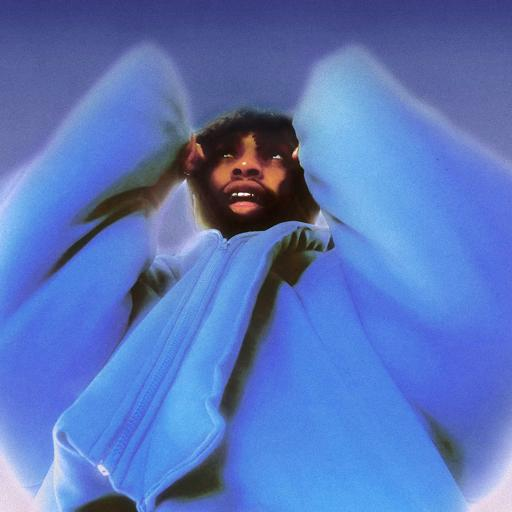

In [10]:
example = list(image_df)[0]
example[0].read()

In [11]:
example

(ImageFile(source='s3://fantaino-bucket-085777795487-us-east-2-an', path='album_art\\$NOT___Ethereal.jpg', size=27229, version='cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr', etag='addc3053ccaf2f6826ad906b9f8bd5fe', is_latest=True, last_modified=datetime.datetime(2026, 5, 2, 8, 8, 28, tzinfo=datetime.timezone.utc), location=None),
 'album_art\\$NOT___Ethereal.jpg')

# Loading from S3 Table Buckets

In [2]:
embeddings_catalog_name = S3_EMBEDDINGS_TABLE_BUCKET_NAME
account_id = get_secret("AWS_ACCOUNT_ID")
s3tablebucketname = S3_EMBEDDINGS_TABLE_BUCKET_NAME
region = get_secret("PYICEBERG_AWS_DEFAULT_REGION")

In [3]:
# Retrieve the S3 embeddings table catalog
embeddings_catalog = retrieve_s3_table_catalog(
    catalog_name=embeddings_catalog_name,
    account_id=account_id,
    s3tablebucketname=s3tablebucketname,
    region=region,
)

# Specify the database and table name for embeddings
small_embeddings_table = embeddings_catalog.load_table(f"{S3_EMBEDDINGS_DATABASE_NAME}.{S3_SMALL_EMBEDDINGS_TABLE}")

# Scan all records in the embeddings table and convert to Pandas DataFrame
all_records_arrow = small_embeddings_table.scan().to_arrow()
embeddings_pd = all_records_arrow.to_pandas()

print(embeddings_pd.head())

                    artist_name                 album_name  embedding_dim_0  \
0                  Little Women                     Throat         0.015394   
1                         Liars                Sisterworld         0.065212   
2             Portugal. The Man            American Ghetto         0.027352   
3                       Melvins  The Bride Screamed Murder         0.042054   
4  Ariel Pinks Haunted Graffiti               Before Today         0.042316   

   embedding_dim_1  embedding_dim_2  embedding_dim_3  embedding_dim_4  \
0        -0.034816        -0.009337         0.014463         0.007346   
1         0.002245         0.001368        -0.005359        -0.017730   
2        -0.017791        -0.001627        -0.011750         0.002927   
3        -0.009212         0.009545        -0.026684        -0.040211   
4        -0.023333        -0.011047        -0.013707        -0.012073   

   embedding_dim_5  embedding_dim_6  embedding_dim_7  ...  embedding_dim_1526  \
0    

In [4]:
# Warehouse must match this S3 Table bucket (not the embeddings bucket from cell 0).
album_data_s3tablebucketname = S3_ALBUM_DATA_TABLE_BUCKET_NAME
album_data_catalog_name = album_data_s3tablebucketname

album_data_catalog = retrieve_s3_table_catalog(
    catalog_name=album_data_catalog_name,
    account_id=account_id,
    s3tablebucketname=album_data_s3tablebucketname,
    region=region,
)

# Database and table name for album metadata Iceberg table
album_data_table = album_data_catalog.load_table(f"{S3_ALBUM_DATA_DATABASE_NAME}.{S3_ALBUM_DATA_TABLE}")

# Scan all records in the album_data table and convert to Pandas DataFrame
all_records_arrow = album_data_table.scan().to_arrow()
album_data_pd = all_records_arrow.to_pandas()

print(album_data_pd.head())

                artist_name       album_name  \
0           Various Artists     Pomegranates   
1               Tame Impala     Innerspeaker   
2                    Harlem          Hippies   
3  The Tallest Man on Earth    The Wild Hunt   
4           Crystal Castles  Crystal Castles   

                               genre_list  rating  total_tracks  \
0                      [abstract hip hop]       8           NaN   
1     [psychedelic rock, neo-psychedelia]       6          11.0   
2               [garage rock, indie surf]       7          16.0   
3  [contemporary folk, singer-songwriter]       8          10.0   
4                      [synthpop, bitpop]       7          17.0   

   num_available_markets  release_year  release_month  release_day  \
0                    NaN           NaN            NaN          NaN   
1                  184.0        2010.0            5.0         21.0   
2                  185.0        2010.0            4.0          5.0   
3                  185.0    

# Creating Multi-Modal Datasets

Earlier, we used a limited size. Now we merge the whole shebang.

In [15]:
image_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/album_art\*",
    type="image", 
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .settings(cache=True)
    .map(path=lambda file: file.path, output=str)
    .persist()
)

In [16]:
embeddings_df = dc.read_pandas(embeddings_pd)

In [5]:
def convert_to_list(x):
    return list(x) if x is not None else None

album_data_pd["genre_list"] = album_data_pd["genre_list"].apply(convert_to_list)
album_data_pd["featured_artists"] = album_data_pd["featured_artists"].apply(convert_to_list)
album_data_pd["track_names"] = album_data_pd["track_names"].apply(convert_to_list)

In [6]:
album_data_df = dc.read_pandas(album_data_pd)

In [7]:
album_data_df.show(3)

Preparing: 0 rows [00:00, ? rows/s]

,artist_name,album_name,genre_list,rating,total_tracks,num_available_markets,release_year,release_month,release_day,album_duration_in_s,explicit_proportion,featured_artists,num_features,track_names,artist_popularity
0,Various Artists,Pomegranates,[abstract hip hop],8,None,None,None,None,None,None,None,None,None,None,None
1,Tame Impala,Innerspeaker,"[psychedelic rock, neo-psychedelia]",6,11.0,184.0,2010.0,5.0,21.0,3201.461,0.0,[Tame Impala],1.0,"[It Is Not Meant To Be, Desire Be Desire Go, A...",89.0
2,Harlem,Hippies,"[garage rock, indie surf]",7,16.0,185.0,2010.0,4.0,5.0,2420.541,0.0,[Harlem],1.0,"[Someday Soon, Friendly Ghost, Spray Paint, Nu...",33.0



[Limited by 3 rows]


In [20]:
embeddings_df.show(3)

Preparing: 0 rows [00:00, ? rows/s]

,artist_name,album_name,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19,embedding_dim_20,embedding_dim_21,embedding_dim_22,embedding_dim_23,embedding_dim_24,embedding_dim_25,embedding_dim_26,embedding_dim_27,embedding_dim_28,embedding_dim_29,embedding_dim_30,embedding_dim_31,embedding_dim_32,embedding_dim_33,embedding_dim_34,embedding_dim_35,embedding_dim_36,embedding_dim_37,embedding_dim_38,embedding_dim_39,embedding_dim_40,embedding_dim_41,embedding_dim_42,embedding_dim_43,embedding_dim_44,embedding_dim_45,embedding_dim_46,embedding_dim_47,embedding_dim_48,embedding_dim_49,embedding_dim_50,embedding_dim_51,embedding_dim_52,embedding_dim_53,embedding_dim_54,embedding_dim_55,embedding_dim_56,embedding_dim_57,embedding_dim_58,embedding_dim_59,embedding_dim_60,embedding_dim_61,embedding_dim_62,embedding_dim_63,embedding_dim_64,embedding_dim_65,embedding_dim_66,embedding_dim_67,embedding_dim_68,embedding_dim_69,embedding_dim_70,embedding_dim_71,embedding_dim_72,embedding_dim_73,embedding_dim_74,embedding_dim_75,embedding_dim_76,embedding_dim_77,embedding_dim_78,embedding_dim_79,embedding_dim_80,embedding_dim_81,embedding_dim_82,embedding_dim_83,embedding_dim_84,embedding_dim_85,embedding_dim_86,embedding_dim_87,embedding_dim_88,embedding_dim_89,embedding_dim_90,embedding_dim_91,embedding_dim_92,embedding_dim_93,embedding_dim_94,embedding_dim_95,embedding_dim_96,embedding_dim_97,embedding_dim_98,embedding_dim_99,embedding_dim_100,embedding_dim_101,embedding_dim_102,embedding_dim_103,embedding_dim_104,embedding_dim_105,embedding_dim_106,embedding_dim_107,embedding_dim_108,embedding_dim_109,embedding_dim_110,embedding_dim_111,embedding_dim_112,embedding_dim_113,embedding_dim_114,embedding_dim_115,embedding_dim_116,embedding_dim_117,embedding_dim_118,embedding_dim_119,embedding_dim_120,embedding_dim_121,embedding_dim_122,embedding_dim_123,embedding_dim_124,embedding_dim_125,embedding_dim_126,embedding_dim_127,embedding_dim_128,embedding_dim_129,embedding_dim_130,embedding_dim_131,embedding_dim_132,embedding_dim_133,embedding_dim_134,embedding_dim_135,embedding_dim_136,embedding_dim_137,embedding_dim_138,embedding_dim_139,embedding_dim_140,embedding_dim_141,embedding_dim_142,embedding_dim_143,embedding_dim_144,embedding_dim_145,embedding_dim_146,embedding_dim_147,embedding_dim_148,embedding_dim_149,embedding_dim_150,embedding_dim_151,embedding_dim_152,embedding_dim_153,embedding_dim_154,embedding_dim_155,embedding_dim_156,embedding_dim_157,embedding_dim_158,embedding_dim_159,embedding_dim_160,embedding_dim_161,embedding_dim_162,embedding_dim_163,embedding_dim_164,embedding_dim_165,embedding_dim_166,embedding_dim_167,embedding_dim_168,embedding_dim_169,embedding_dim_170,embedding_dim_171,embedding_dim_172,embedding_dim_173,embedding_dim_174,embedding_dim_175,embedding_dim_176,embedding_dim_177,embedding_dim_178,embedding_dim_179,embedding_dim_180,embedding_dim_181,embedding_dim_182,embedding_dim_183,embedding_dim_184,embedding_dim_185,embedding_dim_186,embedding_dim_187,embedding_dim_188,embedding_dim_189,embedding_dim_190,embedding_dim_191,embedding_dim_192,embedding_dim_193,embedding_dim_194,embedding_dim_195,embedding_dim_196,embedding_dim_197,embedding_dim_198,embedding_dim_199,embedding_dim_200,embedding_dim_201,embedding_dim_202,embedding_dim_203,embedding_dim_204,embedding_dim_205,embedding_dim_206,embedding_dim_207,embedding_dim_208,embedding_dim_209,embedding_dim_210,embedding_dim_211,embedding_dim_212,embedding_dim_213,embedding_dim_214,embedding_dim_215,embedding_dim_216,embedding_dim_217,embedding_dim_218,embedding_dim_219,embedding_dim_220,embedding_dim_221,embedding_dim_222,embedding_dim_223,embedding_dim_224,embedding_dim_225,embedding_dim_226,


[Limited by 3 rows]


In [7]:
image_df_with_join_key = image_df.map(id=lambda file: file.path.split("\\")[-1].rsplit(".", 1)[0], params=["file"], output=str)
embeddings_df_with_join_key = embeddings_df.map(id=lambda artist_name, album_name: f"{artist_name}___{album_name}", params=["artist_name", "album_name"])
album_data_df_with_join_key = album_data_df.map(id=lambda artist_name, album_name: f"{artist_name}___{album_name}", params=["artist_name", "album_name"])

NameError: name 'image_df' is not defined

In [ ]:
image_df_with_join_key.show(3)

,file,file,path,id
,path,size,,
0,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,$NOT___Ethereal
1,album_art\$uicideboy$___I Want to Die in New O...,38617,album_art\$uicideboy$___I Want to Die in New O...,$uicideboy$___I Want to Die in New Orleans
2,album_art\$uicideboy$___Long Term Effects of S...,443669,album_art\$uicideboy$___Long Term Effects of S...,$uicideboy$___Long Term Effects of SUFFERING



[Limited by 3 rows]


In [23]:
embeddings_df_with_join_key.show(3)

,artist_name,album_name,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19,embedding_dim_20,embedding_dim_21,embedding_dim_22,embedding_dim_23,embedding_dim_24,embedding_dim_25,embedding_dim_26,embedding_dim_27,embedding_dim_28,embedding_dim_29,embedding_dim_30,embedding_dim_31,embedding_dim_32,embedding_dim_33,embedding_dim_34,embedding_dim_35,embedding_dim_36,embedding_dim_37,embedding_dim_38,embedding_dim_39,embedding_dim_40,embedding_dim_41,embedding_dim_42,embedding_dim_43,embedding_dim_44,embedding_dim_45,embedding_dim_46,embedding_dim_47,embedding_dim_48,embedding_dim_49,embedding_dim_50,embedding_dim_51,embedding_dim_52,embedding_dim_53,embedding_dim_54,embedding_dim_55,embedding_dim_56,embedding_dim_57,embedding_dim_58,embedding_dim_59,embedding_dim_60,embedding_dim_61,embedding_dim_62,embedding_dim_63,embedding_dim_64,embedding_dim_65,embedding_dim_66,embedding_dim_67,embedding_dim_68,embedding_dim_69,embedding_dim_70,embedding_dim_71,embedding_dim_72,embedding_dim_73,embedding_dim_74,embedding_dim_75,embedding_dim_76,embedding_dim_77,embedding_dim_78,embedding_dim_79,embedding_dim_80,embedding_dim_81,embedding_dim_82,embedding_dim_83,embedding_dim_84,embedding_dim_85,embedding_dim_86,embedding_dim_87,embedding_dim_88,embedding_dim_89,embedding_dim_90,embedding_dim_91,embedding_dim_92,embedding_dim_93,embedding_dim_94,embedding_dim_95,embedding_dim_96,embedding_dim_97,embedding_dim_98,embedding_dim_99,embedding_dim_100,embedding_dim_101,embedding_dim_102,embedding_dim_103,embedding_dim_104,embedding_dim_105,embedding_dim_106,embedding_dim_107,embedding_dim_108,embedding_dim_109,embedding_dim_110,embedding_dim_111,embedding_dim_112,embedding_dim_113,embedding_dim_114,embedding_dim_115,embedding_dim_116,embedding_dim_117,embedding_dim_118,embedding_dim_119,embedding_dim_120,embedding_dim_121,embedding_dim_122,embedding_dim_123,embedding_dim_124,embedding_dim_125,embedding_dim_126,embedding_dim_127,embedding_dim_128,embedding_dim_129,embedding_dim_130,embedding_dim_131,embedding_dim_132,embedding_dim_133,embedding_dim_134,embedding_dim_135,embedding_dim_136,embedding_dim_137,embedding_dim_138,embedding_dim_139,embedding_dim_140,embedding_dim_141,embedding_dim_142,embedding_dim_143,embedding_dim_144,embedding_dim_145,embedding_dim_146,embedding_dim_147,embedding_dim_148,embedding_dim_149,embedding_dim_150,embedding_dim_151,embedding_dim_152,embedding_dim_153,embedding_dim_154,embedding_dim_155,embedding_dim_156,embedding_dim_157,embedding_dim_158,embedding_dim_159,embedding_dim_160,embedding_dim_161,embedding_dim_162,embedding_dim_163,embedding_dim_164,embedding_dim_165,embedding_dim_166,embedding_dim_167,embedding_dim_168,embedding_dim_169,embedding_dim_170,embedding_dim_171,embedding_dim_172,embedding_dim_173,embedding_dim_174,embedding_dim_175,embedding_dim_176,embedding_dim_177,embedding_dim_178,embedding_dim_179,embedding_dim_180,embedding_dim_181,embedding_dim_182,embedding_dim_183,embedding_dim_184,embedding_dim_185,embedding_dim_186,embedding_dim_187,embedding_dim_188,embedding_dim_189,embedding_dim_190,embedding_dim_191,embedding_dim_192,embedding_dim_193,embedding_dim_194,embedding_dim_195,embedding_dim_196,embedding_dim_197,embedding_dim_198,embedding_dim_199,embedding_dim_200,embedding_dim_201,embedding_dim_202,embedding_dim_203,embedding_dim_204,embedding_dim_205,embedding_dim_206,embedding_dim_207,embedding_dim_208,embedding_dim_209,embedding_dim_210,embedding_dim_211,embedding_dim_212,embedding_dim_213,embedding_dim_214,embedding_dim_215,embedding_dim_216,embedding_dim_217,embedding_dim_218,embedding_dim_219,embedding_dim_220,embedding_dim_221,embedding_dim_222,embedding_dim_223,embedding_dim_224,embedding_dim_225,embedding_dim_226,


[Limited by 3 rows]


In [24]:
multi_modal_df = (
    image_df_with_join_key
    .settings(cache=True)
    .merge(
        embeddings_df_with_join_key, 
        on=dc.C.id,
        inner=False,
        full=False
    )
    .merge(
        album_data_df_with_join_key,
        on=dc.C.id,
        inner=False,
        full=False
    )
    .persist()
)

In [25]:
multi_modal_df.show(3)

,file,file,path,id,artist_name,album_name,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19,embedding_dim_20,embedding_dim_21,embedding_dim_22,embedding_dim_23,embedding_dim_24,embedding_dim_25,embedding_dim_26,embedding_dim_27,embedding_dim_28,embedding_dim_29,embedding_dim_30,embedding_dim_31,embedding_dim_32,embedding_dim_33,embedding_dim_34,embedding_dim_35,embedding_dim_36,embedding_dim_37,embedding_dim_38,embedding_dim_39,embedding_dim_40,embedding_dim_41,embedding_dim_42,embedding_dim_43,embedding_dim_44,embedding_dim_45,embedding_dim_46,embedding_dim_47,embedding_dim_48,embedding_dim_49,embedding_dim_50,embedding_dim_51,embedding_dim_52,embedding_dim_53,embedding_dim_54,embedding_dim_55,embedding_dim_56,embedding_dim_57,embedding_dim_58,embedding_dim_59,embedding_dim_60,embedding_dim_61,embedding_dim_62,embedding_dim_63,embedding_dim_64,embedding_dim_65,embedding_dim_66,embedding_dim_67,embedding_dim_68,embedding_dim_69,embedding_dim_70,embedding_dim_71,embedding_dim_72,embedding_dim_73,embedding_dim_74,embedding_dim_75,embedding_dim_76,embedding_dim_77,embedding_dim_78,embedding_dim_79,embedding_dim_80,embedding_dim_81,embedding_dim_82,embedding_dim_83,embedding_dim_84,embedding_dim_85,embedding_dim_86,embedding_dim_87,embedding_dim_88,embedding_dim_89,embedding_dim_90,embedding_dim_91,embedding_dim_92,embedding_dim_93,embedding_dim_94,embedding_dim_95,embedding_dim_96,embedding_dim_97,embedding_dim_98,embedding_dim_99,embedding_dim_100,embedding_dim_101,embedding_dim_102,embedding_dim_103,embedding_dim_104,embedding_dim_105,embedding_dim_106,embedding_dim_107,embedding_dim_108,embedding_dim_109,embedding_dim_110,embedding_dim_111,embedding_dim_112,embedding_dim_113,embedding_dim_114,embedding_dim_115,embedding_dim_116,embedding_dim_117,embedding_dim_118,embedding_dim_119,embedding_dim_120,embedding_dim_121,embedding_dim_122,embedding_dim_123,embedding_dim_124,embedding_dim_125,embedding_dim_126,embedding_dim_127,embedding_dim_128,embedding_dim_129,embedding_dim_130,embedding_dim_131,embedding_dim_132,embedding_dim_133,embedding_dim_134,embedding_dim_135,embedding_dim_136,embedding_dim_137,embedding_dim_138,embedding_dim_139,embedding_dim_140,embedding_dim_141,embedding_dim_142,embedding_dim_143,embedding_dim_144,embedding_dim_145,embedding_dim_146,embedding_dim_147,embedding_dim_148,embedding_dim_149,embedding_dim_150,embedding_dim_151,embedding_dim_152,embedding_dim_153,embedding_dim_154,embedding_dim_155,embedding_dim_156,embedding_dim_157,embedding_dim_158,embedding_dim_159,embedding_dim_160,embedding_dim_161,embedding_dim_162,embedding_dim_163,embedding_dim_164,embedding_dim_165,embedding_dim_166,embedding_dim_167,embedding_dim_168,embedding_dim_169,embedding_dim_170,embedding_dim_171,embedding_dim_172,embedding_dim_173,embedding_dim_174,embedding_dim_175,embedding_dim_176,embedding_dim_177,embedding_dim_178,embedding_dim_179,embedding_dim_180,embedding_dim_181,embedding_dim_182,embedding_dim_183,embedding_dim_184,embedding_dim_185,embedding_dim_186,embedding_dim_187,embedding_dim_188,embedding_dim_189,embedding_dim_190,embedding_dim_191,embedding_dim_192,embedding_dim_193,embedding_dim_194,embedding_dim_195,embedding_dim_196,embedding_dim_197,embedding_dim_198,embedding_dim_199,embedding_dim_200,embedding_dim_201,embedding_dim_202,embedding_dim_203,embedding_dim_204,embedding_dim_205,embedding_dim_206,embedding_dim_207,embedding_dim_208,embedding_dim_209,embedding_dim_210,embedding_dim_211,embedding_dim_212,embedding_dim_213,embedding_dim_214,embedding_dim_215,embedding_dim_216,embedding_dim_217,embedding_dim_218,embedding_dim_219,embedding_dim_220,embedding_dim_221,embedding_dim_222,embedding_dim_223,embedding_dim_224,embedding_dim_225,


[Limited by 3 rows]


In [26]:
multi_modal_df.count()

3421

## EDA: Missingness

In [27]:
embeddings_pd.shape, embeddings_pd.dropna().shape

((3120, 1538), (3117, 1538))

In [28]:
album_data_pd.shape, album_data_pd.dropna().shape

((3420, 15), (3031, 15))

In [29]:
album_data_pd.describe()

,rating,total_tracks,num_available_markets,release_year,release_month,release_day,album_duration_in_s,explicit_proportion,num_features,artist_popularity
count,3420.000000,3278.000000,3278.000000,3278.000000,3217.000000,3216.000000,3278.000000,3278.000000,3278.000000,3091.000000
mean,6.344444,12.745882,167.947834,2016.967663,6.235934,15.680348,2880.954756,0.316293,3.541794,55.534131
std,1.916374,5.341877,49.094548,7.273056,3.220538,8.762272,1183.146130,0.408903,4.662872,21.936427
min,-2.000000,1.000000,1.000000,1963.000000,1.000000,1.000000,116.366000,0.000000,1.000000,0.000000
25%,5.000000,10.000000,183.000000,2014.000000,3.000000,8.000000,2269.629250,0.000000,1.000000,41.000000
50%,7.000000,12.000000,185.000000,2018.000000,6.000000,16.000000,2684.562500,0.062500,1.000000,57.000000
75%,8.000000,15.000000,185.000000,2022.000000,9.000000,23.000000,3304.289000,0.750000,4.000000,72.000000
max,10.000000,137.000000,185.000000,2026.000000,12.000000,31.000000,19637.281000,1.000000,35.000000,100.000000


# To Do: 

1) Filter to show where missing data is located (when you run on inner like 450 rows disappear).
3) Drop unnecessary columns.
4) Speed up?

# Using raw lyrics instead of embeddings.

In [8]:
image_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/album_art\*",
    type="image", 
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .settings(cache=True)
    .map(path=lambda file: file.path, output=str)
    .persist()
)

In [9]:
image_df.show(3)

,file,file,path
,path,size,
0,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg
1,album_art\$uicideboy$___I Want to Die in New O...,38617,album_art\$uicideboy$___I Want to Die in New O...
2,album_art\$uicideboy$___Long Term Effects of S...,443669,album_art\$uicideboy$___Long Term Effects of S...



[Limited by 3 rows]


In [10]:
from pydantic import BaseModel

class LyricsRow(BaseModel):
    artist: str
    album: str
    tracks: dict

In [ ]:
lyrics_df = (dc.read_json(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/lyrics\*",
    type="text", 
    format="jsonl",
    spec=LyricsRow,
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .persist()
)

In [12]:
lyrics_df.show(3)

,jsonl,jsonl,jsonl
,artist,album,tracks
0,$NOT,Ethereal,"{'My World (Intro)': '[Intro] Ayy, you know so..."
1,$uicideboy$,Long Term Effects of SUFFERING,{'Degeneration in the Key of A Minor': '[Intro...
2,$uicideboy$,I Want to Die in New Orleans,{'King Tulip': '[Intro: Max Beck] They changed...



[Limited by 3 rows]


In [13]:
image_df_with_join_key = image_df.map(id=lambda file: file.path.split("\\")[-1].rsplit(".", 1)[0], params=["file"], output=str)
lyrics_df_with_join_key = lyrics_df.map(id=lambda artist_name, album_name: f"{artist_name}___{album_name}", params=["jsonl.artist", "jsonl.album"])
album_data_df_with_join_key = album_data_df.map(id=lambda artist_name, album_name: f"{artist_name}___{album_name}", params=["artist_name", "album_name"])

In [35]:
multi_modal_df = (
    image_df_with_join_key
    .merge(
        lyrics_df_with_join_key, 
        on=dc.C.id,
        inner=False,
        full=False
    )
    .merge(
        album_data_df_with_join_key,
        on=dc.C.id,
        inner=False,
        full=False
    )
    .persist()
    .save("FantAIno_MultiModal_DF")
)

In [15]:
multi_modal_df.show(3)

,file,file,path,id,jsonl,jsonl,jsonl,right_id,artist_name,album_name,genre_list,rating,total_tracks,num_available_markets,release_year,release_month,release_day,album_duration_in_s,explicit_proportion,featured_artists,num_features,track_names,artist_popularity,right_id_1
,path,size,,,artist,album,tracks,,,,,,,,,,,,,,,,,
0,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,$NOT___Ethereal,$NOT,Ethereal,"{'My World (Intro)': '[Intro] Ayy, you know so...",$NOT___Ethereal,$NOT,Ethereal,[trap],3,14.0,184.0,2022.0,2.0,11.0,2117.807,1.0,"[$NOT, A$AP Rocky, Teddi Jones, Trippie Redd, ...",7.0,"[My World (Intro), Doja, BLUE MOON (feat. Tedd...",None,$NOT___Ethereal
1,album_art\$uicideboy$___I Want to Die in New O...,38617,album_art\$uicideboy$___I Want to Die in New O...,$uicideboy$___I Want to Die in New Orleans,$uicideboy$,I Want to Die in New Orleans,{'King Tulip': '[Intro: Max Beck] They changed...,$uicideboy$___I Want to Die in New Orleans,$uicideboy$,I Want to Die in New Orleans,[trap],6,14.0,185.0,2018.0,9.0,7.0,2549.043,1.0,[$uicideboy$],1.0,"[King Tulip, Bring out Your Dead, Nicotine Pat...",85.0,$uicideboy$___I Want to Die in New Orleans
2,album_art\$uicideboy$___Long Term Effects of S...,443669,album_art\$uicideboy$___Long Term Effects of S...,$uicideboy$___Long Term Effects of SUFFERING,$uicideboy$,Long Term Effects of SUFFERING,{'Degeneration in the Key of A Minor': '[Intro...,$uicideboy$___Long Term Effects of SUFFERING,$uicideboy$,Long Term Effects of SUFFERING,[trap],4,13.0,185.0,2021.0,8.0,13.0,1982.943,1.0,[$uicideboy$],1.0,"[Degeneration in the Key of A Minor, If Self-D...",85.0,$uicideboy$___Long Term Effects of SUFFERING



[Limited by 3 rows]


## MLLM Output with Multimodal Data

In [17]:
# !pip install "transformers[torch]>=5.7.0" torchvision torchcodec

In [148]:
login(token=get_secret("HF_TOKEN_WRITE"))

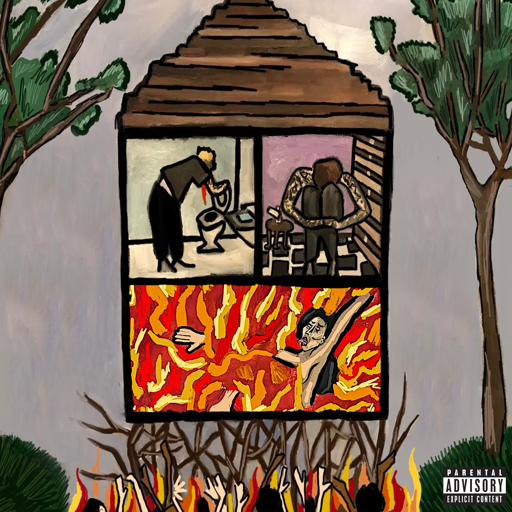

In [19]:
example = list(multi_modal_df)[2]
example[0].read()

In [20]:
multi_modal_df.schema

{'file': datachain.lib.file.ImageFile,
 'path': str,
 'id': str,
 'jsonl': __main__.LyricsRow,
 'right_id': str,
 'artist_name': str,
 'album_name': str,
 'genre_list': list[str],
 'rating': int,
 'total_tracks': float,
 'num_available_markets': float,
 'release_year': float,
 'release_month': float,
 'release_day': float,
 'album_duration_in_s': float,
 'explicit_proportion': float,
 'featured_artists': list[str],
 'num_features': float,
 'track_names': list[str],
 'artist_popularity': float,
 'right_id_1': str}

In [21]:
example

(ImageFile(source='s3://fantaino-bucket-085777795487-us-east-2-an', path='album_art\\$uicideboy$___Long Term Effects of SUFFERING.png', size=443669, version='2UPqQPhOMCmndJpJmZIpZQdUnhz_BnfH', etag='8e45dc18f213177683c74546debc7826', is_latest=True, last_modified=datetime.datetime(2026, 5, 2, 9, 32, tzinfo=datetime.timezone.utc), location=None),
 'album_art\\$uicideboy$___Long Term Effects of SUFFERING.png',
 '$uicideboy$___Long Term Effects of SUFFERING',
 LyricsRow(artist='$uicideboy$', album='Long Term Effects of SUFFERING', tracks={'Degeneration in the Key of A Minor': "[Intro: 2 Low Key]\nBetter stay alert, 'cause I'm spooky with that Jason mask\nSpooky with that Jason mask, spooky with that Jason mask\nYou're all doomed!\nBetter stay alert, 'cause I'm spooky with that Jason mask\nSpooky with that Jason mask, spooky with that Jason mask\nBetter stay alert, 'cause I'm spooky with that Jason mask\nSpooky with that Jason mask, spooky with that Jason mask\nYou're all doomed!\n\n[Verse

In [22]:
album_prompt = {
    'artist_name': example[5],
    'album_name': example[6],
    'genre_list': example[7],
    'rating': example[8],
    'total_tracks': example[9],
    'num_available_markets': example[10],
    'release_year': example[11],
    'release_month': example[12],
    'release_day': example[13],
    'album_duration_in_s': example[14],
    'explicit_proportion': example[15],
    'featured_artists': example[16],
    'num_features': example[17],
    'track_names': example[18],
    'artist_popularity': example[19],
}

album_prompt

{'artist_name': '$uicideboy$',
 'album_name': 'Long Term Effects of SUFFERING',
 'genre_list': ['trap'],
 'rating': 4,
 'total_tracks': 13.0,
 'num_available_markets': 185.0,
 'release_year': 2021.0,
 'release_month': 8.0,
 'release_day': 13.0,
 'album_duration_in_s': 1982.943,
 'explicit_proportion': 1.0,
 'featured_artists': ['$uicideboy$'],
 'num_features': 1.0,
 'track_names': ['Degeneration in the Key of A Minor',
  'If Self-Destruction Was an Olympic Event, I’d Be Tonya Harding',
  'Life Is but a Stream~',
  '5 Grand at 8 to 1',
  'WE ENVY NOTHING IN THE WORLD.',
  'Lighting the Flames of My Own Personal Hell',
  'New Profile Pic',
  'Bleach',
  'Forget It',
  'Avalon',
  'Materialism as a Means to an End',
  'Ugliest',
  'The Number You Have Dialed Is Not in Service'],
 'artist_popularity': 85.0}

In [23]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto",
)

model.eval()

Loading weights: 100%|██████████| 311/311 [00:04<00:00, 65.08it/s] 


Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_attention_layer

In [23]:
messages = [
    {
        "role": "user",
        "content": f"""
            You are a music review score prediction model.

            Task:
            Predict the likely Anthony Fantano / TheNeedleDrop score for this album.

            Album information:
            {album_prompt}

            Score scale:
            -1 = NOT GOOD
            0-10 = integer score

            Rules:
            Return exactly one integer from -1 to 10.
            Do not explain.
            Do not refuse.
            Do not ask for more information.
            """
    }
]

model_inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    enable_thinking=False,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

with torch.inference_mode():
    output = model.generate(
        **model_inputs,
        max_new_tokens=4,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

new_tokens = output[0, model_inputs["input_ids"].shape[-1]:]
pred = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print(pred)

-1


### Making a custom huggingface dataset.

We need to go from DataChain -> Intermediate (maybe) -> HuggingFace Dataset

In [ ]:
import datachain as dc
from datasets import Dataset, Features, Image, Value, Sequence
import numpy as np

# 1. Load your DataChain
chain = dc.read_dataset("FantAIno_MultiModal_DF")  # <-- change this

records = []

# 2. Loop over tuples and pick out what we need by position
for row in chain:
    # --- Pick out the pieces ---
    file_obj    = row[0]   # ImageFile object (the album cover)
    album_id    = row[2]
    lyrics_row  = row[3]   # This is the LyricsRow with the tracks dict
    artist      = row[5]
    album       = row[6]
    genre_list  = row[7]
    rating      = row[8]
    total_tracks = row[9]
    num_markets = row[10]
    release_year = row[11]
    release_month = row[12]
    release_day = row[13]
    duration    = row[14]
    explicit    = row[15]
    featured    = row[16]
    num_features = row[17]
    track_names = row[18]
    popularity  = row[19]

    # --- Read the image bytes from S3 ---
    try:
        img_bytes = file_obj.read()
    except AttributeError:
        # If .read() doesn't exist, try getting a local path first
        local_path = file_obj.get_local_path()
        with open(local_path, "rb") as f:
            img_bytes = f.read()

    # --- Convert the tracks dict to a list (way better for ML) ---
    # lyrics_row.tracks looks like: {"My World (Intro)": "[Intro]...", "Doja": "..."}
    tracks_list = []
    if lyrics_row is not None and hasattr(lyrics_row, "tracks") and lyrics_row.tracks is not None:
        for track_name, lyrics in lyrics_row.tracks.items():
            tracks_list.append({
                "name": track_name,
                "lyrics": lyrics
            })
    # If lyrics_row is None or has no tracks, tracks_list remains empty.
 

    # --- Helper to fix NaN values ---
    def clean_num(val, default=0.0):
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return default
        return val

    # --- Build the record ---
    records.append({
        "image": img_bytes,
        "album_id": album_id,
        "artist": artist,
        "album": album,
        "tracks": tracks_list,
        "genre_list": list(genre_list) if genre_list else [],
        "rating": int(clean_num(rating, 0)),
        "total_tracks": clean_num(total_tracks),
        "num_available_markets": clean_num(num_markets),
        "release_year": clean_num(release_year),
        "release_month": clean_num(release_month),
        "release_day": clean_num(release_day),
        "album_duration_in_s": clean_num(duration),
        "explicit_proportion": clean_num(explicit),
        "featured_artists": list(featured) if featured else [],
        "num_features": clean_num(num_features),
        "track_names": list(track_names) if track_names else [],
        "artist_popularity": clean_num(popularity),
    })

print(f"✅ Processed {len(records)} albums!")

In [45]:
# 3. Tell HuggingFace what each column is
features = Features({
    "image": Image(),
    "album_id": Value("string"),
    "artist": Value("string"),
    "album": Value("string"),
    "tracks": [{
        "name": Value("string"),
        "lyrics": Value("string")
    }],
    "genre_list": Sequence(Value("string")),
    "rating": Value("int8"),
    "total_tracks": Value("float32"),
    "num_available_markets": Value("float32"),
    "release_year": Value("float32"),
    "release_month": Value("float32"),
    "release_day": Value("float32"),
    "album_duration_in_s": Value("float32"),
    "explicit_proportion": Value("float32"),
    "featured_artists": Sequence(Value("string")),
    "num_features": Value("float32"),
    "track_names": Sequence(Value("string")),
    "artist_popularity": Value("float32"),
})

# 4. Create the dataset
dataset = Dataset.from_list(records, features=features)

In [46]:
# 5. Push to HuggingFace Hub
# (Make sure you ran `huggingface-cli login` in your terminal first!)
dataset.push_to_hub("roromaniac/FantAIno")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 3/3 [00:00<00:00,  4.71ba/s]
Processing Files (1 / 1): 100%|██████████|  293MB /  293MB, 1.42MB/s  
New Data Upload: 100%|██████████|  288MB /  288MB, 1.42MB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [03:26<00:00, 206.62s/ shards]


CommitInfo(commit_url='https://huggingface.co/datasets/roromaniac/FantAIno/commit/1e3d6cc64506ff01e0676ce4384a4dc7f7aa9654', commit_message='Upload dataset', commit_description='', oid='1e3d6cc64506ff01e0676ce4384a4dc7f7aa9654', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/roromaniac/FantAIno', endpoint='https://huggingface.co', repo_type='dataset', repo_id='roromaniac/FantAIno'), pr_revision=None, pr_num=None)

# Finetuning with an (M)LLM

This will primarily be emulating the [Fine-tuning demo present at HuggingFace](https://huggingface.co/docs/transformers/en/training).

In [160]:
raw_labels = list(range(-2, 11))
id2label_classification = {idx: str(label) for idx, label in enumerate(raw_labels)}
label2id_classification = {str(label): idx for idx, label in enumerate(raw_labels)}

id2label_regression = {0: "RATING"}
label2id_regression = {"RATING": 0}

In [161]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=1,
    dtype="auto",
    id2label=id2label_regression,
    label2id=label2id_regression,
    problem_type="regression"
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10154.47it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [162]:
MAX_LENGTH = 512

def tokenize(batch):
    return tokenizer(
        batch["text"],
        trucnation=True,
        max_length=MAX_LENGTH
    )

In [163]:
training_args = TrainingArguments(
    output_dir=f"FantAIno_{model_name}",
    num_train_epochs=100,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    bf16=True,
    learning_rate=2e-5,
    logging_steps=8,
    eval_steps=25,
    logging_strategy="steps",
    eval_strategy="steps",
    save_strategy="best",
    load_best_model_at_end=True,
    report_to="none",
    disable_tqdm=True
)

# Fine Tuning w/ HuggingFace Dataset

In [2]:
dataset = load_dataset("roromaniac/FantAIno", split="train")
dataset = dataset.train_test_split(test_size=0.1)

In [8]:
dataset["train"]["rating"]

Column([7, 7, 5, 7, 7, ...])

In [166]:
def format_for_regression(ex):
    text = f"""
Artist: {ex["artist"]}
Album: {ex["album"]}
Genres: {ex["genre_list"]}
Tracks: {ex["track_names"]}
Featured Arists: {ex["featured_artists"]}
Release Year: {ex["release_year"]}
Release Month: {ex["release_month"]}
Album Duration (in seconds): {ex["album_duration_in_s"]}
Artist Popularity: {ex["artist_popularity"]}
"""
    return {
        "text": text,
        "labels": float(ex["rating"]),
    }

In [167]:
regression_dataset = dataset.map(format_for_regression).select_columns(["text", "labels"])

In [168]:
regression_dataset = regression_dataset.map(tokenize, batched=True)

In [169]:
accuracy = evaluate.load("accuracy")

def rounded_accuracy(eval_pred):
    predictions, labels = eval_pred
    predictions = np.ravel(np.clip(np.rint(predictions), -1, 10).astype(np.int32))
    labels = labels.astype(np.int32)
    return accuracy.compute(predictions=predictions, references=labels)

In [170]:
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=0.0005
)

In [171]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=regression_dataset["train"],
    eval_dataset=regression_dataset["test"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=rounded_accuracy,
    callbacks=[early_stopping_callback]
)

{'loss': '299.9', 'grad_norm': '885.8', 'learning_rate': '1.999e-05', 'epoch': '0.04159'}
{'loss': '184.8', 'grad_norm': '766.7', 'learning_rate': '1.998e-05', 'epoch': '0.08317'}
{'loss': '127.7', 'grad_norm': '628.6', 'learning_rate': '1.998e-05', 'epoch': '0.1248'}
{'eval_loss': '11.04', 'eval_accuracy': '0.08163', 'eval_runtime': '4.393', 'eval_samples_per_second': '78.08', 'eval_steps_per_second': '9.789', 'epoch': '0.13'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.33s/it]


{'loss': '85.12', 'grad_norm': '350.4', 'learning_rate': '1.997e-05', 'epoch': '0.1663'}
{'loss': '61.34', 'grad_norm': '539.9', 'learning_rate': '1.996e-05', 'epoch': '0.2079'}
{'loss': '54.46', 'grad_norm': '540.3', 'learning_rate': '1.995e-05', 'epoch': '0.2495'}
{'eval_loss': '4.698', 'eval_accuracy': '0.1254', 'eval_runtime': '4.236', 'eval_samples_per_second': '80.97', 'eval_steps_per_second': '10.15', 'epoch': '0.2599'}


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.10s/it]


{'loss': '38.88', 'grad_norm': '272', 'learning_rate': '1.994e-05', 'epoch': '0.2911'}
{'loss': '34.93', 'grad_norm': '184.1', 'learning_rate': '1.993e-05', 'epoch': '0.3327'}
{'loss': '33.76', 'grad_norm': '155.9', 'learning_rate': '1.993e-05', 'epoch': '0.3743'}
{'eval_loss': '3.453', 'eval_accuracy': '0.2362', 'eval_runtime': '4.206', 'eval_samples_per_second': '81.55', 'eval_steps_per_second': '10.22', 'epoch': '0.3899'}


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.68it/s]


{'loss': '31.25', 'grad_norm': '102.3', 'learning_rate': '1.966e-05', 'epoch': '1.702'}
{'loss': '20.08', 'grad_norm': '127.9', 'learning_rate': '1.965e-05', 'epoch': '1.743'}
{'loss': '27.02', 'grad_norm': '171.6', 'learning_rate': '1.964e-05', 'epoch': '1.785'}
{'eval_loss': '3.375', 'eval_accuracy': '0.2711', 'eval_runtime': '4.381', 'eval_samples_per_second': '78.29', 'eval_steps_per_second': '9.815', 'epoch': '1.816'}
{'loss': '26.33', 'grad_norm': '113.5', 'learning_rate': '1.964e-05', 'epoch': '1.827'}
{'loss': '25.53', 'grad_norm': '252', 'learning_rate': '1.963e-05', 'epoch': '1.868'}
{'loss': '40.02', 'grad_norm': '130.1', 'learning_rate': '1.962e-05', 'epoch': '1.91'}
{'eval_loss': '3.264', 'eval_accuracy': '0.2245', 'eval_runtime': '4.312', 'eval_samples_per_second': '79.55', 'eval_steps_per_second': '9.973', 'epoch': '1.946'}
{'loss': '29.84', 'grad_norm': '247.8', 'learning_rate': '1.961e-05', 'epoch': '1.951'}
{'loss': '30.28', 'grad_norm': '168.8', 'learning_rate': '1.9

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]


{'loss': '24.97', 'grad_norm': '131.4', 'learning_rate': '1.953e-05', 'epoch': '2.364'}
{'loss': '28.64', 'grad_norm': '721.9', 'learning_rate': '1.952e-05', 'epoch': '2.405'}
{'loss': '26.57', 'grad_norm': '407.2', 'learning_rate': '1.951e-05', 'epoch': '2.447'}
{'eval_loss': '3.254', 'eval_accuracy': '0.2886', 'eval_runtime': '4.338', 'eval_samples_per_second': '79.07', 'eval_steps_per_second': '9.912', 'epoch': '2.463'}
{'loss': '19.97', 'grad_norm': '120.9', 'learning_rate': '1.95e-05', 'epoch': '2.489'}
{'loss': '24.14', 'grad_norm': '283', 'learning_rate': '1.95e-05', 'epoch': '2.53'}
{'loss': '26.55', 'grad_norm': '220.8', 'learning_rate': '1.949e-05', 'epoch': '2.572'}
{'eval_loss': '3.213', 'eval_accuracy': '0.2653', 'eval_runtime': '4.329', 'eval_samples_per_second': '79.24', 'eval_steps_per_second': '9.934', 'epoch': '2.593'}
{'loss': '24.87', 'grad_norm': '112.5', 'learning_rate': '1.948e-05', 'epoch': '2.613'}
{'loss': '24.27', 'grad_norm': '166.4', 'learning_rate': '1.947

HfHubHTTPError: (Request ID: Root=1-6a1ef8a4-2a7c1660052569c85f83672a;88b8b38e-df3a-4298-9595-849d4989ef6d)

403 Forbidden: You don't have the rights to create a model under the namespace "roromaniac".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.

In [ ]:
trainer.train()

In [ ]:
login(token=get_secret("HF_TOKEN_WRITE"))

trainer.push_to_hub()

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.71it/s]
Processing Files (0 / 1):  26%|██▌       | 70.3MB /  268MB, 1.30MB/s  

In [151]:
regression_dataset["test"][0]

{'text': '\nArtist: Protomartyr\nAlbum: Formal Growth in the Desert\nGenres: [\'post-punk\', \'art punk\']\nTracks: [\'Make Way\', \'For Tomorrow\', \'Elimination Dances\', \'Fun In Hi Skool\', "Let\'s Tip the Creator", \'Graft Vs. Host\', \'3800 Tigers\', \'Polacrilex Kid\', \'Fulfillment Center\', \'We Know the Rats\', \'The Author\', \'Rain Garden\']\nFeatured Arists: [\'Protomartyr\']\nRelease Year: 2023.0\nRelease Month: 6.0\nAlbum Duration (in seconds): 2260.507080078125\nArtist Popularity: 39.0\n',
 'labels': 6.0,
 'input_ids': [101,
  3063,
  1024,
  15053,
  22345,
  12541,
  2201,
  1024,
  5337,
  3930,
  1999,
  1996,
  5532,
  11541,
  1024,
  1031,
  1005,
  2695,
  1011,
  7196,
  1005,
  1010,
  1005,
  2396,
  7196,
  1005,
  1033,
  3162,
  1024,
  1031,
  1005,
  2191,
  2126,
  1005,
  1010,
  1005,
  2005,
  4826,
  1005,
  1010,
  1005,
  9614,
  11278,
  1005,
  1010,
  1005,
  4569,
  1999,
  7632,
  15315,
  13669,
  1005,
  1010,
  1000,
  2292,
  1005,
  1055

In [154]:
from transformers import pipeline

login(token=get_secret("HF_TOKEN_READ"))

FantAIno_rating_predictor = pipeline("text-classification", model=f"roromaniac/FantAIno_{model_name}")
FantAIno_rating_predictor(
    "\nArtist: Lil Uzi Vert\nAlbum: Lil Uzi Vert vs. the World\nGenres: ['trap', 'pop rap']\nTracks: ['Canadian Goose', 'Hi Roller', 'Money Longer', 'Grab the Wheel', 'You Was Right', 'Baby Are You Home', 'Ps & Qs', 'Team Rocket', 'Scott and Ramona']\nFeatured Arists: ['Lil Uzi Vert']\nRelease Year: 2016.0\nRelease Month: 5.0\nAlbum Duration (in seconds): 2032.4169921875\nArtist Popularity: 86.0\n"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9131.03it/s]


[{'label': 'RATING', 'score': 3.399127960205078}]

In [ ]:
regression_dataset = regression_dataset.map(tokenize, batched=True)